# 🚀 Stock Market Prediction System
## Random Forest & Sentiment Analysis Hybrid Model

**Pipeline Steps:**
1. Data Collection
2. Data Preprocessing
3. Feature Engineering
4. Model Training & Evaluation
5. Baseline Comparison
6. Backtesting (Walk-Forward Validation)

## 📦 Setup and Imports

In [ ]:
import sys
import os

import config
from config import (
   print_config
)
# Add src directory to path so we can import modules
sys.path.append(os.path.join(os.getcwd(), 'src'))
from src.data_collection import (
    download_stock_data,
    download_multiple_stocks,
    load_stock_data
)
from src.preprocessing import preprocess_stock_data
from src.feature_engineering import engineer_all_features, prepare_ml_data
from src.models import train_and_evaluate_pipeline, compare_baseline
from src.backtesting import walk_forward_validation, compare_strategies, plot_backtest_results

print("✅ All imports successful!")

✅ Imported necessary libraries
✅ Imported config settings
✅ All imports successful!


## ⚙️ Configuration

Display current configuration settings:

In [5]:
import config
# Print configuration
config.print_config()

STOCK PREDICTION PROJECT CONFIGURATION
Tickers: AAPL, MSFT, GOOGL, AMZN, TSLA
Date Range: 2023-04-23 to 2026-04-22
Rolling Windows: [5, 10, 20]
Volatility Window: 20 days
Momentum Window: 5 days
Prediction Horizon: 1 day(s)
Test Size: 20.0%
Random Forest Estimators: 100
Max Depth: 15
Min Samples Split: 5
Min Samples Leaf: 2
Backtesting Splits: 5
Verbose Logging: True


## 🔧 Function Definitions

### Pipeline for Single Stock

In [6]:
import config
def run_complete_pipeline(ticker, start_date=None, end_date=None):
    """
    Run the complete ML pipeline for a single stock

    This function orchestrates all steps:
    1. Data Collection
    2. Preprocessing
    3. Feature Engineering
    4. Model Training
    5. Evaluation
    6. Backtesting

    Args:
        ticker (str): Stock ticker symbol (e.g., 'AAPL')
        start_date (str): Start date for data (default from config)
        end_date (str): End date for data (default from config)

    Returns:
        dict: Results from all pipeline steps
    """
    if start_date is None:
        start_date = config.START_DATE
    if end_date is None:
        end_date = config.END_DATE

    print("\\n" + "=" * 80)
    print(" " * 20 + f"STOCK PREDICTION PIPELINE: {ticker}")
    print("=" * 80)
    print(f"Date Range: {start_date} to {end_date}")
    print("=" * 80 + "\\n")

    # ========================================================================
    # STEP 1: DATA COLLECTION
    # ========================================================================
    print("\\n" + "🔵 " * 30)
    print("STEP 1: DATA COLLECTION")
    print("🔵 " * 30)

    # Try to load existing data first
    raw_data = load_stock_data(ticker, 'raw')

    if raw_data is None:
        # Download if not found
        print(f"No existing data found. Downloading {ticker}...")
        raw_data = download_stock_data(ticker, start_date, end_date, save=True)

        if raw_data is None:
            print(f"❌ Failed to download data for {ticker}")
            return None
    else:
        print(f"✅ Loaded existing data for {ticker}")

    print(f"Raw data shape: {raw_data.shape}")

    # ========================================================================
    # STEP 2: DATA PREPROCESSING
    # ========================================================================
    print("\\n" + "🟢 " * 30)
    print("STEP 2: DATA PREPROCESSING")
    print("🟢 " * 30)

    processed_data = preprocess_stock_data(
        raw_data,
        save_path=config.get_data_path(ticker, 'processed')
    )

    print(f"Processed data shape: {processed_data.shape}")

    # ========================================================================
    # STEP 3: FEATURE ENGINEERING
    # ========================================================================
    print("\\n" + "🟡 " * 30)
    print("STEP 3: FEATURE ENGINEERING")
    print("🟡 " * 30)

    feature_data = engineer_all_features(processed_data)

    # Save feature data
    feature_path = config.get_data_path(ticker, 'features')
    feature_data.to_csv(feature_path, index=False)
    print(f"Saved feature data to: {feature_path}")

    # Prepare for ML
    X, y, feature_names = prepare_ml_data(feature_data)

    print(f"\\nFinal dataset:")
    print(f"  Samples: {len(X)}")
    print(f"  Features: {len(feature_names)}")
    print(f"  Target distribution: {y.value_counts().to_dict()}")

    # ========================================================================
    # STEP 4: MODEL TRAINING & EVALUATION
    # ========================================================================
    print("\\n" + "🔴 " * 30)
    print("STEP 4: MODEL TRAINING & EVALUATION")
    print("🔴 " * 30)

    # Run complete training pipeline
    model_results = train_and_evaluate_pipeline(X, y, feature_names)

    # ========================================================================
    # STEP 5: BASELINE COMPARISON
    # ========================================================================
    print("\\n" + "🟣 " * 30)
    print("STEP 5: BASELINE COMPARISON")
    print("🟣 " * 30)

    comparison = compare_baseline(
        model_results['X_train'],
        model_results['y_train'],
        model_results['X_test'],
        model_results['y_test']
    )

    # ========================================================================
    # STEP 6: BACKTESTING
    # ========================================================================
    print("\\n" + "🟠 " * 30)
    print("STEP 6: BACKTESTING (Walk-Forward Validation)")
    print("🟠 " * 30)

    backtest_results = walk_forward_validation(X, y, feature_names,
                                               n_splits=config.N_SPLITS)

    # Plot backtesting results
    print("\nGenerating backtesting visualization...")
    plot_backtest_results(backtest_results)

    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================
    print("\\n" + "=" * 80)
    print(" " * 25 + "PIPELINE COMPLETE!")
    print("=" * 80)

    print(f"\\n📊 FINAL RESULTS FOR {ticker}:")
    print("-" * 80)
    print(f"Test Set Accuracy:        {model_results['metrics']['test_accuracy']:.2%}")
    print(f"Backtesting Mean Accuracy: {backtest_results['accuracy'].mean():.2%}")
    print(f"Backtesting Std:          {backtest_results['accuracy'].std():.4f}")

    if comparison['improvement'] > 0:
        print(f"\\nSentiment features improved accuracy by: {comparison['improvement']:.2%}")
    else:
        print(f"\\nSentiment features did not improve accuracy")

    print("\\n" + "=" * 80)

    # Return all results
    return {
        'ticker': ticker,
        'raw_data': raw_data,
        'processed_data': processed_data,
        'feature_data': feature_data,
        'X': X,
        'y': y,
        'feature_names': feature_names,
        'model_results': model_results,
        'comparison': comparison,
        'backtest_results': backtest_results
    }

print("✅ Function defined: run_complete_pipeline()")


✅ Function defined: run_complete_pipeline()


### Pipeline for Multiple Stocks

In [9]:
def run_multiple_stocks(tickers=None):
    """
    Run pipeline for multiple stocks

    Args:
        tickers (list): List of ticker symbols (default from config)

    Returns:
        dict: Results for each ticker
    """
    if tickers is None:
        tickers = config.TICKERS

    print("\\n" + "=" * 80)
    print(" " * 15 + f"RUNNING PIPELINE FOR {len(tickers)} STOCKS")
    print("=" * 80)
    print(f"Tickers: {', '.join(tickers)}")
    print("=" * 80 + "\\n")

    results = {}

    for idx, ticker in enumerate(tickers, 1):
        print(f"\\n{'=' * 80}")
        print(f" " * 20 + f"PROCESSING {ticker} ({idx}/{len(tickers)})")
        print(f"{'=' * 80}\\n")

        try:
            ticker_results = run_complete_pipeline(ticker)
            if ticker_results is not None:
                results[ticker] = ticker_results
                # Plot backtesting results for this ticker
                print(f"\n📊 Plotting backtesting results for {ticker}...")
                plot_backtest_results(ticker_results['backtest_results'])
                print(f"\n✅ Successfully processed {ticker}")
        except Exception as e:
            print(f"\n❌ Error processing {ticker}: {e}")
            continue

    # Summary across all stocks
    print("\\n" + "=" * 80)
    print(" " * 20 + "MULTI-STOCK SUMMARY")
    print("=" * 80)

    for ticker, result in results.items():
        test_acc = result['model_results']['metrics']['test_accuracy']
        backtest_acc = result['backtest_results']['accuracy'].mean()
        print(f"{ticker:6s} - Test: {test_acc:.2%}, Backtest: {backtest_acc:.2%}")

    return results

print("✅ Function defined: run_multiple_stocks()")

✅ Function defined: run_multiple_stocks()


## ▶️ Execution Section

Choose one of the options below to run the pipeline:

### Option 1: Run Pipeline for Single Stock


\n================================================================================
                    STOCK PREDICTION PIPELINE: AAPL
Date Range: 2023-04-23 to 2026-04-22
================================================================================\n
\n🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 
STEP 1: DATA COLLECTION
🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 🔵 
✅ Loaded 9143 rows from d:\machine learning\Machine Learning Project\stock_ml_project\data\raw\AAPL_raw.csv
✅ Loaded existing data for AAPL
Raw data shape: (9143, 7)
\n🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 
STEP 2: DATA PREPROCESSING
🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 

PREPROCESSING PIPELINE

Step 1: Cleaning data...
⚠️  Missing values found:
Date      1
Close     1
High      1
Low       1
Open      1
Volume    1
Ticker    1
dtype: int64

Step 2: Handling missing values...
Dropped 1 rows with missing values

Step 3: Validating data...
✅ Data v

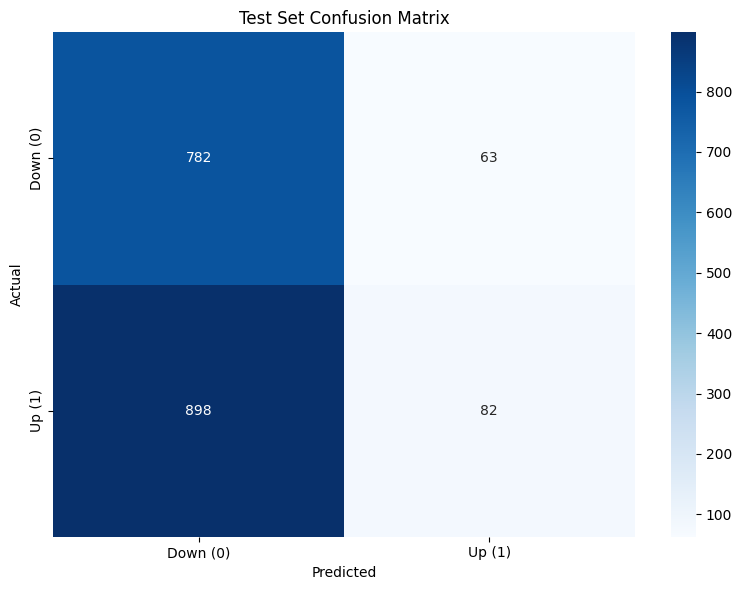


Confusion Matrix Breakdown:
  True Negatives (predicted down, was down):  782
  False Positives (predicted up, was down):   63
  False Negatives (predicted down, was up):   898
  True Positives (predicted up, was up):      82


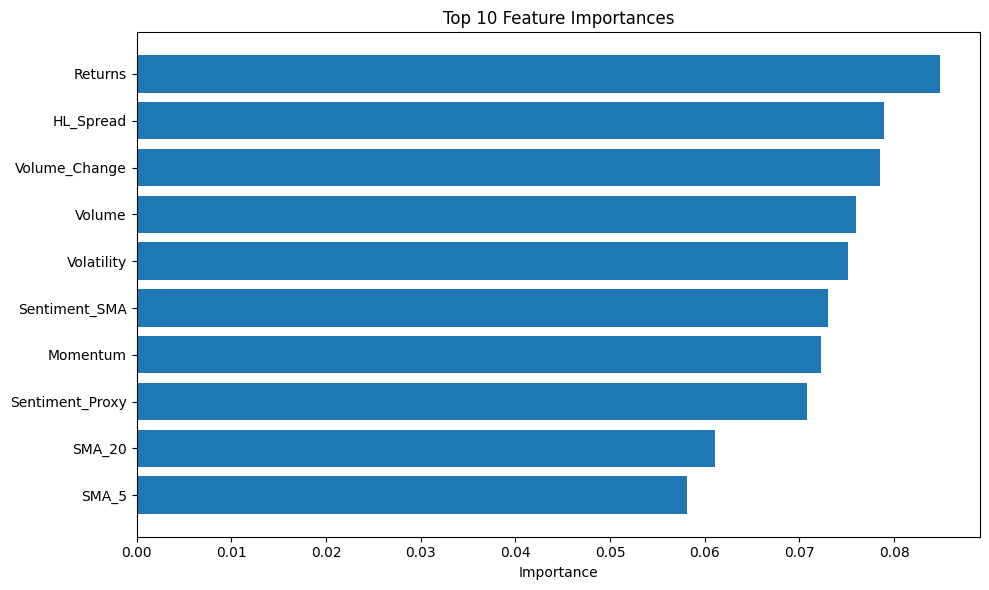


Top 10 Features:
  Returns: 0.0848
  HL_Spread: 0.0789
  Volume_Change: 0.0785
  Volume: 0.0760
  Volatility: 0.0751
  Sentiment_SMA: 0.0730
  Momentum: 0.0723
  Sentiment_Proxy: 0.0708
  SMA_20: 0.0611
  SMA_5: 0.0582

                    PIPELINE COMPLETE!
\n🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 
STEP 5: BASELINE COMPARISON
🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 🟣 

BASELINE COMPARISON

1. Training BASELINE model (price features only)...

TRAINING RANDOM FOREST MODEL
Parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 10, 'n_jobs': -1}

Training model...
✅ Model training complete!

2. Training HYBRID model (price + sentiment features)...

TRAINING RANDOM FOREST MODEL
Parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 10, 'n_jobs': -1}

Training model...
✅ Model training complete!

RESULTS:
Baseline (price-only) accuracy

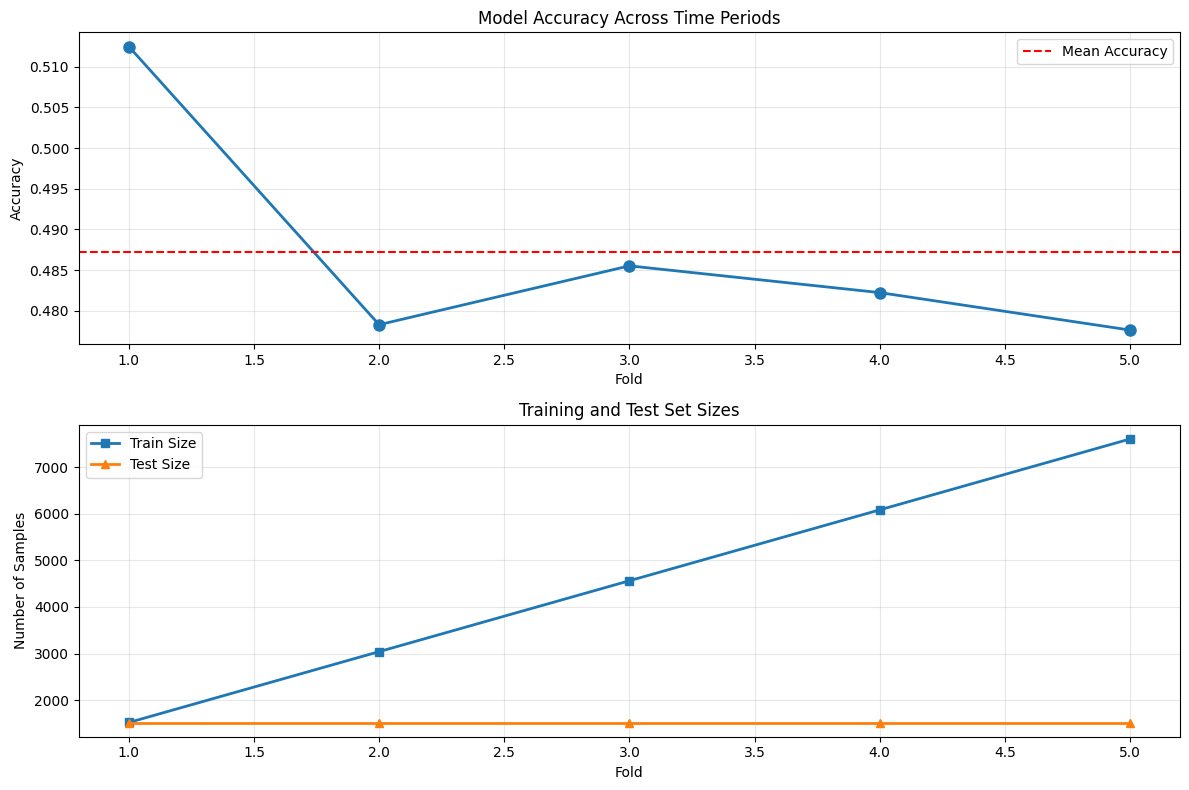

\n================================================================================
                         PIPELINE COMPLETE!
\n📊 FINAL RESULTS FOR AAPL:
--------------------------------------------------------------------------------
Test Set Accuracy:        47.34%
Backtesting Mean Accuracy: 48.72%
Backtesting Std:          0.0145
\nSentiment features improved accuracy by: 0.22%
\n================================================================================


In [8]:
# Run pipeline for AAPL

results_single = run_complete_pipeline('AAPL')

### Option 2: Run Pipeline for Multiple Stocks (from config)

Runs for all stocks defined in `config.TICKERS`

In [2]:
# Run pipeline for all configured stocks
# Uncomment the line below to execute

results_multiple = run_multiple_stocks()

NameError: name 'run_multiple_stocks' is not defined

## 📊 Results Analysis

After running one of the pipeline options above, use these cells to analyze results:

### View Single Stock Results

In [ ]:
# Uncomment and run after executing Option 1

if 'results_single' in locals():
    print("\\n📈 Model Metrics:")
    print(results_single['model_results']['metrics'])
    print("\\n📊 Backtesting Results:")
    print(f"Mean Accuracy: {results_single['backtest_results']['accuracy'].mean():.2%}")
    print(f"Std: {results_single['backtest_results']['accuracy'].std():.4f}")
else:
    print("No single stock results available. Run Option 1 first.")

### View Multiple Stocks Comparison

In [ ]:
# Uncomment and run after executing Option 2 or 3

# if 'results_multiple' in locals():
#     import pandas as pd
#     
#     summary_data = []
#     for ticker, result in results_multiple.items():
#         summary_data.append({
#             'Ticker': ticker,
#             'Test Accuracy': result['model_results']['metrics']['test_accuracy'],
#             'Backtest Mean': result['backtest_results']['accuracy'].mean(),
#             'Backtest Std': result['backtest_results']['accuracy'].std(),
#             'Features': len(result['feature_names'])
#         })
#     
#     summary_df = pd.DataFrame(summary_data)
#     print("\\n📊 Multi-Stock Summary:")
#     print(summary_df.to_string(index=False))
# else:
#     print("No multiple stock results available. Run Option 2 or 3 first.")

In [ ]:
# Download data for all configured stocks (preparation step)
# Uncomment the line below to execute

print("\\nDownloading data for all configured stocks...")
data_dict = download_multiple_stocks(
    config.TICKERS,
    config.START_DATE,
    config.END_DATE,
    save=True
)
print(f"\\n✅ Downloaded data for {len(data_dict)} stocks")